#  Diabetes Data Analysis Project


## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [2]:
df = pd.read_csv("../Data/raw_pima_dataset.csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Basic Information

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## Check Missing Values

df.isnull().sum()

## Handle Invalid Zero Values (Preprocessing)

In [4]:
cols = ["Glucose", "BMI", "BloodPressure", "Insulin"]

for col in cols:
    df[col] = df[col].replace(0, np.nan)
    

df.fillna(df.median(), inplace=True)

## Create New Features (Feature Engineering)

## Age Group

In [5]:
df['Age_Group'] = pd.cut(df['Age'],
                        bins=[20, 30, 40, 50, 60, 100],
                        labels=['20-30', '30-40', '40-50', '50-60', '60+'])

## BMI Category

In [6]:
df['BMI_Category'] = pd.cut(df['BMI'],
                           bins=[0, 18.5, 24.9, 29.9, 100],
                           labels=['Underweight', 'Normal', 'Overweight', 'Obese'])

# Univariate Analysis

## Distribution of Glucose

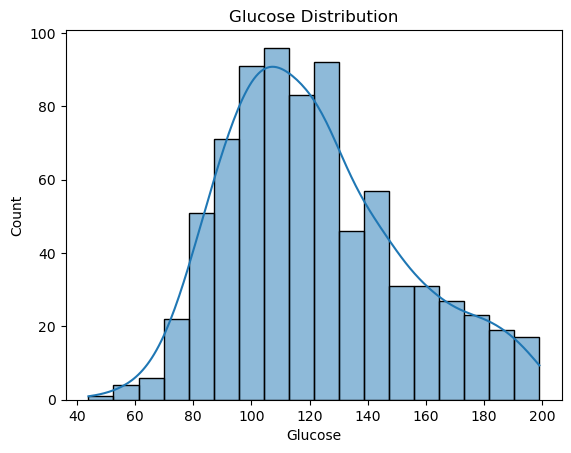

In [7]:
plt.figure()
sns.histplot(df['Glucose'], kde=True)
plt.title("Glucose Distribution")
plt.show()

## Outcome Count

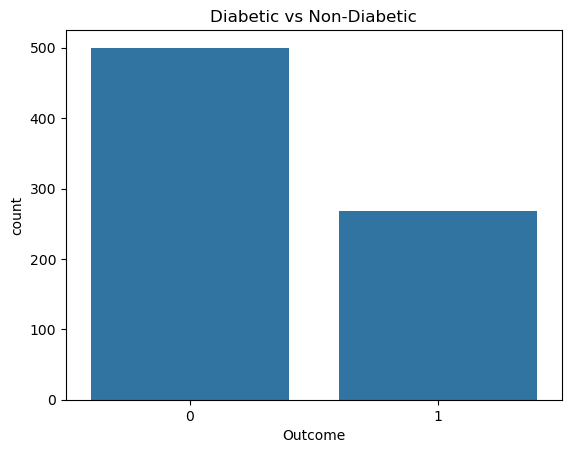

In [8]:
sns.countplot(x='Outcome', data=df)
plt.title("Diabetic vs Non-Diabetic")
plt.show()

# Bivariate Analysis

## Glucose vs Outcome

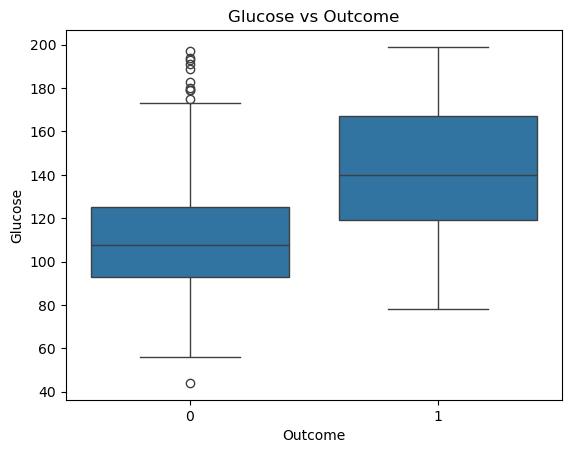

In [9]:
sns.boxplot(x='Outcome', y='Glucose', data=df)
plt.title("Glucose vs Outcome")
plt.show()

## BMI vs Outcome

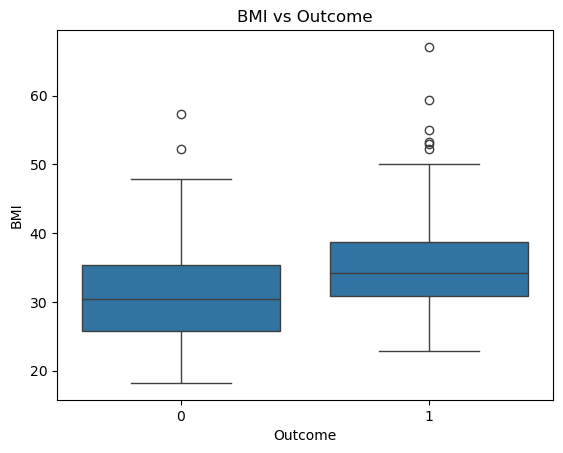

In [10]:
sns.boxplot(x='Outcome', y='BMI', data=df)
plt.title("BMI vs Outcome")
plt.show()

## Correlation Heatmap

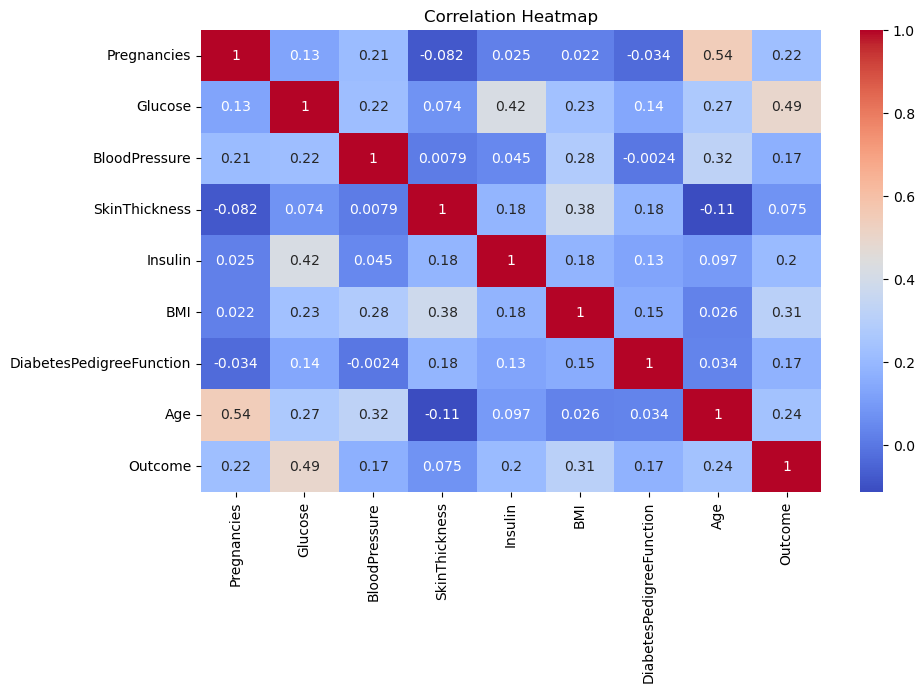

In [11]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## Save Cleaned Dataset

In [12]:
df.to_csv("cleaned_diabetes.csv", index=False)

## WHO Dataset Quick EDA

### Since the data is already cleaned we just going to perform basic EDA 

In [13]:
who_df = pd.read_csv("../Data/WHO_raw_dataset.csv")

who_df.head()
who_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6930 entries, 0 to 6929
Data columns (total 4 columns):
 #   Column                                                                                                                    Non-Null Count  Dtype  
---  ------                                                                                                                    --------------  -----  
 0   Entity                                                                                                                    6930 non-null   object 
 1   Code                                                                                                                      6685 non-null   object 
 2   Year                                                                                                                      6930 non-null   int64  
 3   Raised fasting blood glucose (>=7.0 mmol/L) (age-standardized estimate) - Sex: both sexes - Age group: 18+  years of age  6930 non-nul

## Rename column for better Understanding

In [14]:
who_df.rename(columns={
    "Raised fasting blood glucose (>=7.0 mmol/L) (age-standardized estimate) - Sex: both sexes - Age group: 18+  years of age": "Diabetes_Prevalence"
}, inplace=True)

## Trend Plot:

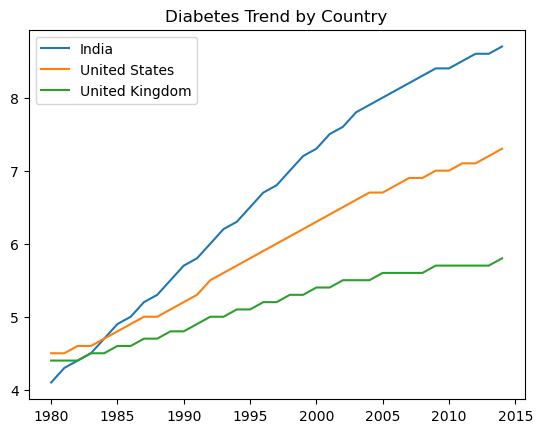

In [15]:
plt.figure()
for country in ["India", "United States", "United Kingdom"]:
    temp = who_df[who_df['Entity'] == country]
    plt.plot(temp['Year'], temp['Diabetes_Prevalence'], label=country)

plt.legend()
plt.title("Diabetes Trend by Country")
plt.show()

## Key Insights From WHO Dataset:

- Diabetes increased steadily in all three countries from 1980–2015
- India showed the fastest growth, ending with the highest value
- The UK had the slowest rise, while the exact metric remains unclear due to missing y-axis context

# Save cleaned WHO dataset

In [16]:
who_df.to_csv("../Data/clean_who_dataset.csv", index=False)

## Connect Pima Indians Diabetes Dataset  to PostgreSQL for further analysis

In [17]:
import os
from sqlalchemy import create_engine

username = os.environ.get('PG_USER', 'postgres')
password = os.environ.get('PG_PASSWORD', '')
host = os.environ.get('PG_HOST', 'localhost')
port = os.environ.get('PG_PORT', '5432')
database = os.environ.get('PG_DB', 'Diabetes_analysis')

engine = create_engine(f'postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}')

df.to_sql('diabetes', engine, if_exists='replace', index=False)
print(f'Data loaded into PostgreSQL table: diabetes')

Data loaded into PostgreSQL table: diabetes


## Connect  WHO global Diabetes Dataset  to PostgreSQL for further analysis

In [18]:
import os
from sqlalchemy import create_engine

username = os.environ.get('PG_USER', 'postgres')
password = os.environ.get('PG_PASSWORD', '')
host = os.environ.get('PG_HOST', 'localhost')
port = os.environ.get('PG_PORT', '5432')
database = os.environ.get('PG_DB', 'Diabetes_analysis')

engine = create_engine(f'postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}')

who_df.to_sql('global_diabetes', engine, if_exists='replace', index=False)
print(f'Data loaded into PostgreSQL table: global_diabetes')

Data loaded into PostgreSQL table: global_diabetes
